In [5]:
import sys; print(sys.executable)

C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
sns.set_theme(style="darkgrid")

In [7]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
df = pd.read_excel("Wk 01 - Supply Chain Dataset.xlsx", header=4)

In [9]:
df.head()

,TransactionID,Date,Product_Name,Category,Supplier,Units_Ordered,Units_Received,Units_Sold,Stock_On_Hand,Lead_Time_Days,Stockout_Flag,Region
0,SCL00001,2024-05-04,Bread 400g,Bakery,Bidco Africa,138,122,30,139,14,No,Ngong Road
1,SCL00002,2024-01-27,Chicken 1kg,Meat,Twiga Foods,255,249,41,223,8,No,Westlands
2,SCL00003,2023-02-20,Sugar 2kg,Grocery,Bidco Africa,363,362,313,114,4,No,Eastleigh
3,SCL00004,2023-07-13,Eggs Tray 30,Eggs,Twiga Foods,63,60,55,105,14,No,Kiambu
4,SCL00005,2024-06-16,Pampers Size 4,Baby,Export Trading Group,65,56,33,92,8,No,Karen


In [10]:
df.shape

(4500, 12)

In [11]:
df.dtypes

TransactionID                str
Date              datetime64[us]
Product_Name                 str
Category                     str
Supplier                     str
Units_Ordered              int64
Units_Received             int64
Units_Sold                 int64
Stock_On_Hand              int64
Lead_Time_Days             int64
Stockout_Flag                str
Region                       str
dtype: object

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   TransactionID   4500 non-null   str           
 1   Date            4500 non-null   datetime64[us]
 2   Product_Name    4500 non-null   str           
 3   Category        4500 non-null   str           
 4   Supplier        4500 non-null   str           
 5   Units_Ordered   4500 non-null   int64         
 6   Units_Received  4500 non-null   int64         
 7   Units_Sold      4500 non-null   int64         
 8   Stock_On_Hand   4500 non-null   int64         
 9   Lead_Time_Days  4500 non-null   int64         
 10  Stockout_Flag   4500 non-null   str           
 11  Region          4500 non-null   str           
dtypes: datetime64[us](1), int64(5), str(6)
memory usage: 422.0 KB


In [13]:
# 1. Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df = df.sort_values(by = 'Date', ascending = True)

In [15]:
df = df.reset_index(drop=True)

In [16]:
# 2. Extract Year, Month, Quater, and DayOfWeek as new columns
df["Year"] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()

In [17]:
df.head()

,TransactionID,Date,Product_Name,Category,Supplier,Units_Ordered,Units_Received,Units_Sold,Stock_On_Hand,Lead_Time_Days,Stockout_Flag,Region,Year,Month,Quarter,DayOfWeek
0,SCL02126,2023-01-01,Indomie Noodles,Noodles,Chandaria Industries,324,290,235,76,16,No,Westlands,2023,1,1,Sunday
1,SCL00278,2023-01-01,Brookside Milk 500ml,Dairy,Twiga Foods,205,193,107,92,5,No,Westlands,2023,1,1,Sunday
2,SCL00112,2023-01-01,Colgate 100g,Personal Care,Brookside Dairy,158,135,107,69,7,No,Westlands,2023,1,1,Sunday
3,SCL00168,2023-01-01,Sugar 2kg,Grocery,Unga Group,356,333,184,197,5,No,Thika Road,2023,1,1,Sunday
4,SCL03970,2023-01-01,Bread 400g,Bakery,Bidco Africa,406,359,253,197,14,No,Mombasa Road,2023,1,1,Sunday


In [18]:
# Finding the start date, end date, and calculate the total duration
start_date = df['Date'].min()
end_date = df['Date'].max()
duration = end_date - start_date

# Print the results
print(f"First Date: {start_date.strftime('%Y-%m-%d')}")
print(f"Last Date: {end_date.strftime('%Y-%m-%d')}")
print(f"Total Duration: {duration.days} days")

First Date: 2023-01-01
Last Date: 2024-12-31
Total Duration: 730 days


In [19]:
df.isnull().sum()

TransactionID     0
Date              0
Product_Name      0
Category          0
Supplier          0
Units_Ordered     0
Units_Received    0
Units_Sold        0
Stock_On_Hand     0
Lead_Time_Days    0
Stockout_Flag     0
Region            0
Year              0
Month             0
Quarter           0
DayOfWeek         0
dtype: int64

In [20]:
# 1. Create a boolean mask to find where Units_Received is greater than Units_Ordered
anomaly_mask = df['Units_Received'] >  df['Units_Ordered']

# 2. Count how many rows have this issue
anomaly_count = anomaly_mask.sum()
print(f"Number of logical anomaly rows found: {anomaly_count}")

# 3. View the actual rows that are broken (if any exist)
if anomaly_count > 0:
  print("\n-- Displaying Anomaly Rows --- ")
  display(df[anomaly_mask][['TransactionID', 'Supplier', 'Units_Ordered', 'Units_Received']])

Number of logical anomaly rows found: 0


In [21]:
duplicate_count = df.duplicated('TransactionID').sum()
print(f"Duplicate TransactionID Count: {duplicate_count}")



Duplicate TransactionID Count: 0


Calculating the Data Quality Score

In [23]:
# Calculate total cells and total issues (missing values)

total_cells = df.size
total_issues = df.isnull().sum().sum()

#2. Calculate the Data Quality Score
data_quality_score = (1- (total_issues / total_cells)) * 100

# 3. Print the result

print(f"Total Cells: {total_cells}")
print(f"Total Issues (Nulls): {total_issues}")
print(f"Data Quality Score: {data_quality_score:.2f}%")



Total Cells: 72000
Total Issues (Nulls): 0
Data Quality Score: 100.00%


Exploratory Analysis( 5 questions to answer)

In [24]:
#1. Calculate the stockout rate directly using the lambda function
stockout_rate = df.groupby('Category')['Stockout_Flag'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)


# Print the results
print("--- Stockout Rate by Product Category ---")
print(stockout_rate)


--- Stockout Rate by Product Category ---
Category
Dairy            6.690141
Baby             4.895105
Noodles          4.666667
Produce          4.530201
Bakery           4.207120
Personal Care    3.508772
Detergent        3.496503
Grocery          3.355705
Eggs             3.202847
Oil              2.816901
Meat             2.719033
Tea              2.416918
Flour            2.395210
Grain            2.033898
Name: Stockout_Flag, dtype: float64


In [25]:
# Group by Supplier and calculate the mean of Lead_Time_Days, sorted from longest to shortest
lead_time = df.groupby('Supplier')['Lead_Time_Days'].mean().sort_values(ascending=False)
print(lead_time)

Supplier
Brookside Dairy         11.819172
Chandaria Industries    11.784355
Bakeries Ltd            11.779621
Export Trading Group    11.666667
KWAL                    11.605701
KFC Supply              11.484513
Unga Group              11.432558
Twiga Foods             11.415966
Pembe Flour             11.220000
Bidco Africa            11.211581
Name: Lead_Time_Days, dtype: float64


Text(0.5, 1.0, 'Avg Lead Time by Supplier')

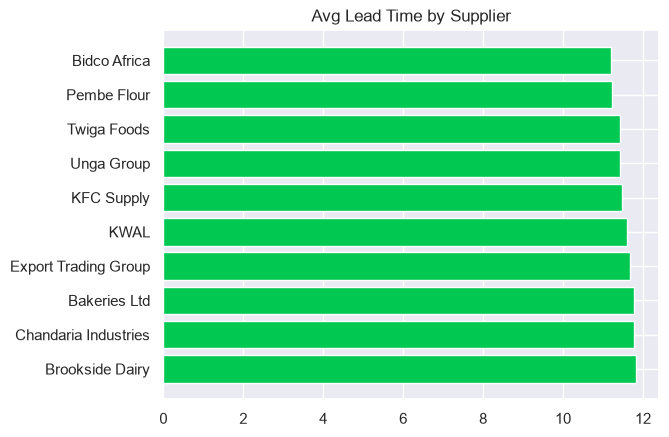

In [26]:
# 2. Plot the longest average lead times
plt.barh(lead_time.index, lead_time.values, color='#00C851')
plt.title('Avg Lead Time by Supplier')

In [27]:
# 3. Filter for stockouts and group by Year and Month to count occurrences
monthly_stockouts = df[df['Stockout_Flag'] == 'Yes'].groupby(['Year', 'Month']).size().reset_index(name='Count')

# Display the summary table
print(monthly_stockouts)

    Year  Month  Count
0   2023      1      7
1   2023      2      5
2   2023      3      4
3   2023      4      7
4   2023      5      6
5   2023      6      6
6   2023      7      7
7   2023      8     13
8   2023      9      7
9   2023     10     10
10  2023     11      8
11  2023     12      6
12  2024      1      3
13  2024      2     10
14  2024      3      4
15  2024      4      6
16  2024      5      4
17  2024      6      6
18  2024      7      8
19  2024      8      5
20  2024      9      7
21  2024     10     11
22  2024     11      7
23  2024     12      8


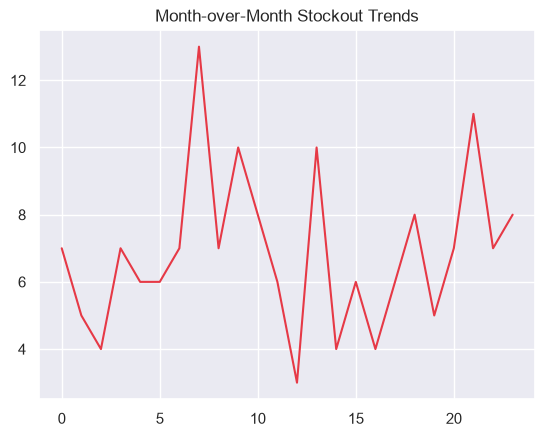

In [28]:
# Plot the seasonal month-over-month stockout trend line chart
plt.plot(monthly_stockouts['Count'], color='#E63946')
plt.title('Month-over-Month Stockout Trends')

plt.show()

In [29]:
#4. Group by Region and sum the total number of stockouts, sorted from worst to best
region_stockout = df.groupby('Region')['Stockout_Flag'].apply(lambda x: (x == 'Yes').sum()).sort_values(ascending=False)

# Display the results
print(region_stockout)

Region
Westlands       28
Thika Road      26
Mombasa Road    25
Ngong Road      23
Kiambu          22
Karen           21
Eastleigh       20
Name: Stockout_Flag, dtype: int64


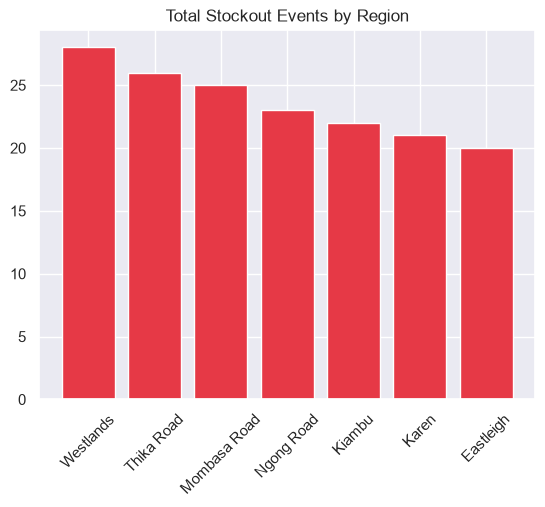

In [30]:
# 2. Create the visualization
plt.bar(region_stockout.index, region_stockout.values, color='#E63946')
plt.title('Total Stockout Events by Region')
plt.xticks(rotation=45)

plt.show()

In [31]:
# 5. Calculate the fulfillment rate for each row
df['Fulfillment_Rate'] = df['Units_Received'] / df['Units_Ordered'] * 100

# 2. Group by Supplier and calculate the average fulfillment rate, sorted lowest to highest
fulfillment = df.groupby('Supplier')['Fulfillment_Rate'].mean().sort_values()

# Display the results
print(fulfillment)

Supplier
Export Trading Group    92.367176
Twiga Foods             92.437708
Brookside Dairy         92.474968
Bakeries Ltd            92.530397
Pembe Flour             92.663247
Unga Group              92.698041
KFC Supply              92.732610
Bidco Africa            92.736927
Chandaria Industries    92.840188
KWAL                    92.895590
Name: Fulfillment_Rate, dtype: float64


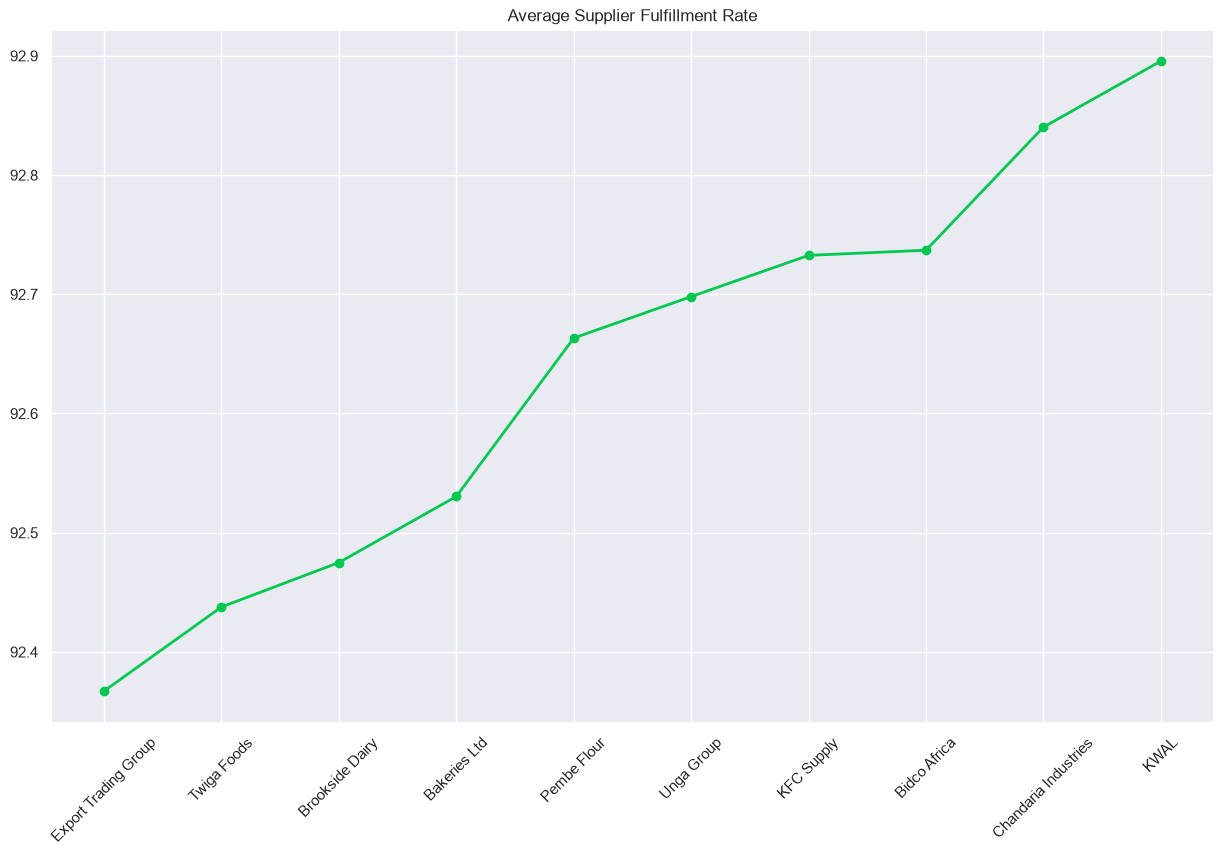

In [32]:
# Plot the fulfillment rate chart
plt.figure(figsize=(15, 9))
plt.plot(fulfillment.index, fulfillment.values, color='#00C851', marker='o', linewidth=2)
plt.title('Average Supplier Fulfillment Rate')
plt.xticks(rotation=45)

plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_11388\3021695456.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(stockout_rate.index, rotation=45, ha='right')
C:\Users\pc\AppData\Local\Temp\ipykernel_11388\3021695456.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 2].set_xticklabels(monthly_stockouts['Period'], rotation=45, ha='right')
C:\Users\pc\AppData\Local\Temp\ipykernel_11388\3021695456.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(region_stockout.index, rotation=45, ha='right')
C:\Users\pc\AppData\Local\Temp\ipykernel_11388\3021695456.py:45: UserWarning: 

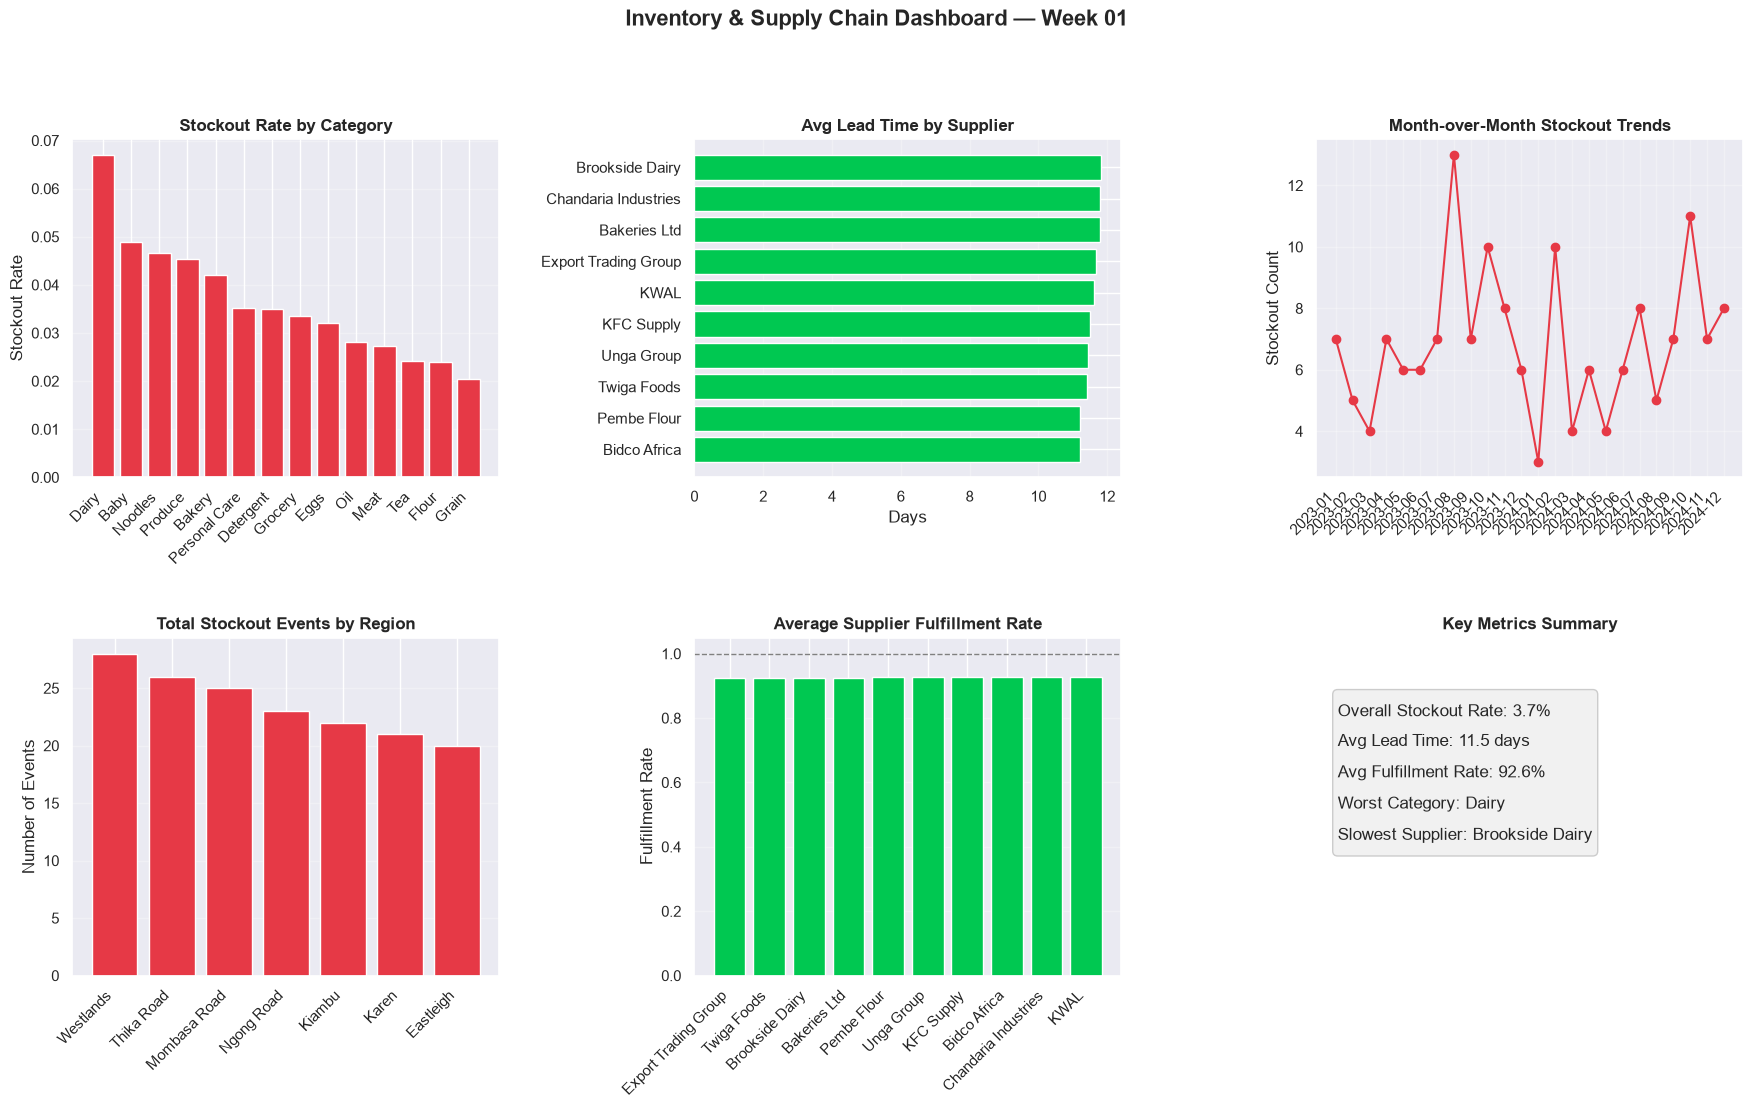

In [33]:
# 1. Create the 2x3 grid canvas
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Inventory & Supply Chain Dashboard — Week 01', fontsize=16, fontweight='bold', y=1.02)

# --- Q1: Product Categories Stockout Rate (Top Left) ---
stockout_rate = df.groupby('Category')['Stockout_Flag'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
axes[0, 0].bar(stockout_rate.index, stockout_rate.values, color='#E63946')
axes[0, 0].set_title('Stockout Rate by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Stockout Rate')
axes[0, 0].set_xticklabels(stockout_rate.index, rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3)

# --- Q2: Supplier Lead Times (Top Middle) ---
lead_time = df.groupby('Supplier')['Lead_Time_Days'].mean().sort_values(ascending=False)
axes[0, 1].barh(lead_time.index, lead_time.values, color='#00C851')
axes[0, 1].set_title('Avg Lead Time by Supplier', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Days')
axes[0, 1].invert_yaxis()  # highest lead time on top
axes[0, 1].grid(axis='x', alpha=0.3)

# --- Q3: Seasonal Trends (Top Right) ---
monthly_stockouts = df[df['Stockout_Flag'] == 'Yes'].groupby(['Year', 'Month']).size().reset_index(name='Count')
monthly_stockouts['Period'] = monthly_stockouts['Year'].astype(str) + '-' + monthly_stockouts['Month'].astype(str).str.zfill(2)
monthly_stockouts = monthly_stockouts.sort_values('Period')
axes[0, 2].plot(monthly_stockouts['Period'], monthly_stockouts['Count'], color='#E63946', marker='o')
axes[0, 2].set_title('Month-over-Month Stockout Trends', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Stockout Count')
axes[0, 2].set_xticklabels(monthly_stockouts['Period'], rotation=45, ha='right')
axes[0, 2].grid(alpha=0.3)

# --- Q4: Regional Stockouts (Bottom Left) ---
region_stockout = df[df['Stockout_Flag'] == 'Yes'].groupby('Region').size().sort_values(ascending=False)
axes[1, 0].bar(region_stockout.index, region_stockout.values, color='#E63946')
axes[1, 0].set_title('Total Stockout Events by Region', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Events')
axes[1, 0].set_xticklabels(region_stockout.index, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# --- Q5: Supplier Fulfillment Rate (Bottom Middle) ---
df['Fulfillment_Rate'] = df['Units_Received'] / df['Units_Ordered']
fulfillment = df.groupby('Supplier')['Fulfillment_Rate'].mean().sort_values()
axes[1, 1].bar(fulfillment.index, fulfillment.values, color='#00C851')
axes[1, 1].set_title('Average Supplier Fulfillment Rate', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Fulfillment Rate')
axes[1, 1].set_xticklabels(fulfillment.index, rotation=45, ha='right')
axes[1, 1].axhline(1.0, color='gray', linestyle='--', linewidth=1)  # 100% reference line
axes[1, 1].grid(axis='y', alpha=0.3)

# --- Bottom Right: Summary KPI Panel ---
axes[1, 2].axis('off')
summary_text = (
    f"Overall Stockout Rate: {(df['Stockout_Flag'] == 'Yes').mean():.1%}\n"
    f"Avg Lead Time: {df['Lead_Time_Days'].mean():.1f} days\n"
    f"Avg Fulfillment Rate: {df['Fulfillment_Rate'].mean():.1%}\n"
    f"Worst Category: {stockout_rate.index[0]}\n"
    f"Slowest Supplier: {lead_time.index[0]}"
)
axes[1, 2].text(0.05, 0.6, summary_text, fontsize=12, va='center', linespacing=2,
                 bbox=dict(boxstyle='round', facecolor='#f1f1f1', edgecolor='#ccc'))
axes[1, 2].set_title('Key Metrics Summary', fontsize=12, fontweight='bold')

# Adjust layout and save the dashboard file
plt.tight_layout(pad=2.0, h_pad=3.0, w_pad=2.5)
plt.savefig('week01_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()